# Synthetic Binary Data: Decision Tree Foundations and ID3

## Project Overview

This notebook develops the core mechanics of decision trees through a small binary classification problem. The complete tree-building process is traced from attribute selection and entropy to information gain, recursive splitting, stopping conditions, and scikit-learn verification.

### Technical Coverage

- Decision-tree structure and interpretation
- Appropriate use cases for decision trees
- ID3 tree-induction workflow
- Majority-class reasoning
- Entropy
- Two equivalent entropy implementations
- Information gain
- Recursive split construction
- Pure-node stopping conditions
- Numerical encoding of categorical attributes
- Tree-depth control
- Decision-tree visualization with scikit-learn

## 1. Decision Tree Structure

A decision tree is a flowchart-like predictive model. Internal nodes represent attributes or decision rules, branches represent attribute outcomes, and leaf nodes represent predicted classes.

### Example Decision Tree

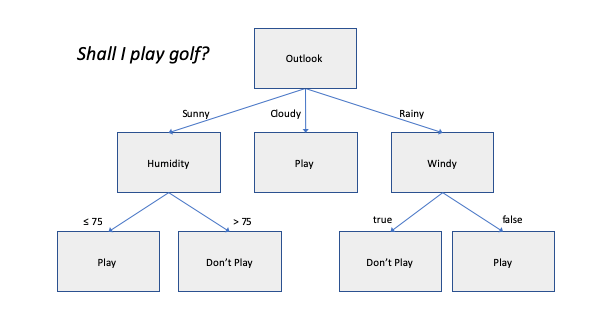

Decision trees are especially useful when interpretability is important and the predictive relationship can be represented through a sequence of attribute-based decisions.

### Typical Conditions Where Decision Trees Are Useful

- observations can be described using attribute-value pairs
- the target is discrete for classification
- disjunctive decision rules may be useful
- training data may contain noise
- attributes may contain missing values
- human interpretability is important
- the target may depend strongly on only a subset of available attributes

## 2. ID3 Tree Induction

The ID3 algorithm recursively selects the attribute that best separates the current examples, creates branches for the attribute values, and continues until a stopping condition is reached.

The foundational ID3 formulation introduced by Quinlan is available at:
https://link.springer.com/article/10.1007/BF00116251

### ID3 Pseudocode

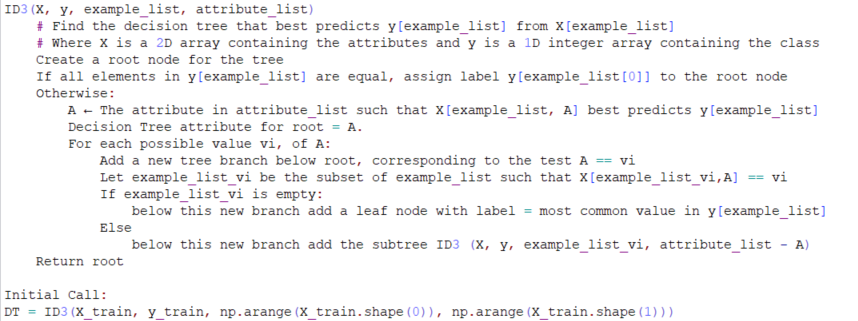

At each internal node, the central problem is selecting the next attribute:

\[
A \leftarrow \text{attribute that best predicts } y
\]

for the examples currently reaching that node.

## 3. Step-by-Step Binary Classification Example

The following dataset contains eight observations, three categorical attributes (`a0`, `a1`, `a2`), and a binary target.

Let's consider a binary classification case.

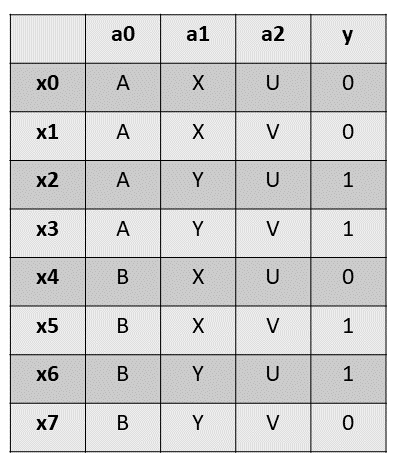

The initial tree-building call uses all eight examples and all three candidate attributes. The first decision is which attribute should become the root.

The target contains four positive and four negative examples, so a classifier predicting only the majority class would achieve 0.50 accuracy before any split.

### Candidate Split: `a0`

For both values of `a0`, the resulting subsets contain `[2+, 2-]`. A majority-class prediction would therefore achieve 0.50 accuracy in each branch.

### Candidate Split: `a1`

The two `a1` branches produce `[1+, 3-]` and `[3+, 1-]`. A majority-class prediction would achieve 0.75 accuracy in each branch.

### Candidate Split: `a2`

Both `a2` branches again contain `[2+, 2-]`, producing 0.50 majority-class accuracy.

This comparison suggests that `a1` is the strongest root candidate. Entropy and information gain provide the formal criterion.

## 4. Entropy

For a binary label set \(S\),

\[
H(S) = -p(0)\log_2 p(0) - p(1)\log_2 p(1)
\]

Entropy is zero for a pure node and reaches its maximum when both classes occur with equal probability.

### Entropy Implementation Using the Mean of Binary Labels

In [1]:

import numpy as np
def entropy(S):
  p1 = np.mean(S)
  p0 = 1-p1
  if p0==0 or p1==0:
    return 0
  return -p0*np.log2(p0) - p1*np.log2(p1)

### Entropy Examples

In [2]:
S = [0,0,0,0,1,1,1,1]
entropy(S)

np.float64(1.0)

In [3]:
S = [0,0,0,0]
entropy(S)

0

In [4]:
S = [1,1,1,1]
entropy(S)

0

In [5]:
S = [0,1,1,1]
entropy(S)

np.float64(0.8112781244591328)

In [6]:
S = [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
entropy(S)

np.float64(0.18312206830137284)

### Equivalent Entropy Implementation Using Class Counts

A second source implementation computes \(p(1)\) explicitly as the number of positive labels divided by the number of labels. It is retained because it demonstrates the same calculation through a distinct implementation.

In [7]:
import numpy as np
def entropy(S):
  p1 = np.sum(S)/len(S)
  p0 = 1-p1
  if p0==0 or p1==0:
    return 0
  return -p0*np.log2(p0) - p1*np.log2(p1)

### Entropy as a Function of the Positive-Class Probability

In [8]:
def entropy_from_p1(p1):
  p0 = 1-p1
  if p0==0 or p1==0:
    return 0
  return -p0*np.log2(p0) - p1*np.log2(p1)

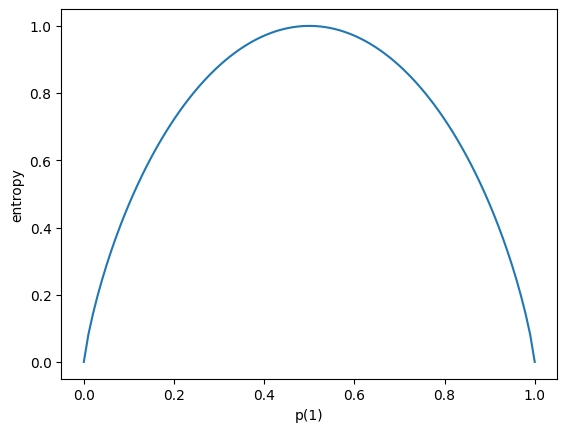

In [9]:
import matplotlib.pyplot as plt

p1 = np.linspace(0,1,100) # Generates 100 values from 0 to 1, unifirmly spaced

ent = []
for p in p1:
  ent.append(entropy_from_p1(p))

plt.plot(p1,ent)
plt.xlabel('p(1)')
plt.ylabel('entropy')
plt.show()


### Auxiliary Mean Calculation

This numerical mean calculation is retained from the source implementations as a separate NumPy computation.

In [10]:
np.mean([0.1,0.15,3.4,3.2,3.3,3.1])

np.float64(2.208333333333333)

## 5. Information Gain

Information gain measures the reduction in entropy created by splitting a dataset on an attribute.

For the root-node example, the candidate attributes are evaluated directly.

### Information Gain for `a0`

In [11]:
G = entropy_from_p1(0.5) - (4/8)*entropy_from_p1(0.5) - (4/8)*entropy_from_p1(0.5)
print(G)

0.0


### Information Gain for `a1`

In [12]:
G = entropy_from_p1(0.5) - (4/8)*entropy_from_p1(0.25) - (4/8)*entropy_from_p1(0.75)
print(G)

0.1887218755408671


### Information Gain for `a2`

In [13]:
G = entropy_from_p1(0.5) - (4/8)*entropy_from_p1(0.5) - (4/8)*entropy_from_p1(0.5)
print(G)

0.0


### Entropy Check at \(p(1)=0.25\)

In [14]:
entropy_from_p1(0.25)

np.float64(0.8112781244591328)

The largest information gain is obtained with `a1`, so `a1` becomes the root attribute.

## 6. Recursive Tree Construction

After choosing `a1`, the dataset is partitioned and ID3 is applied recursively to each branch.

### First Split

For the recursive calls, we would split the dataset according to **a1**.

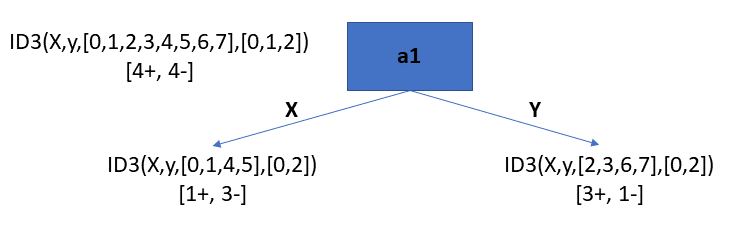

The table representation below shows how the observations are separated into subsets as the tree grows.

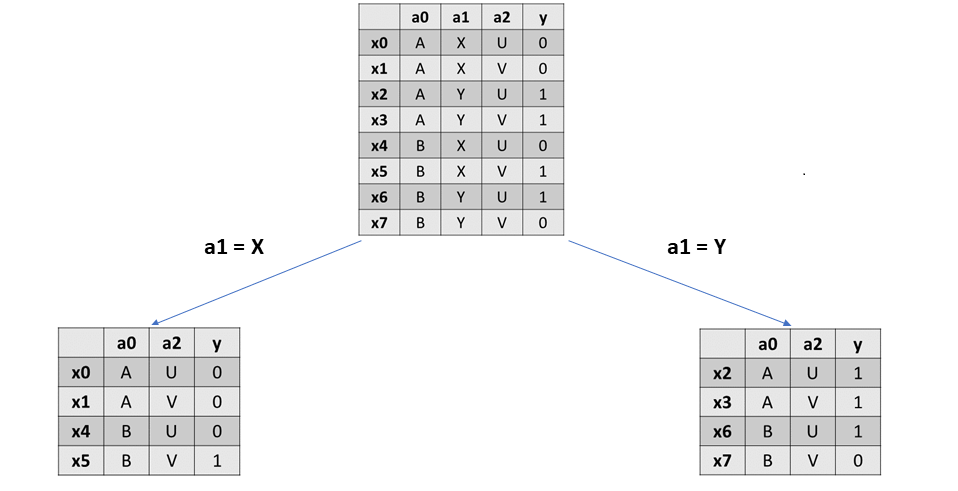

### Selecting the Next Attribute

For the left child of the root, the remaining candidate attributes are `a0` and `a2`.

#### Information Gain for `a0`

In [15]:
G = entropy_from_p1(0.25) - (2/4)*entropy_from_p1(0) - (2/4)*entropy_from_p1(0.5)
print(G)

0.31127812445913283


#### Information Gain for `a2`

In [16]:
G = entropy_from_p1(0.25) - (2/4)*entropy_from_p1(0) - (2/4)*entropy_from_p1(0.5)
print(G)

0.31127812445913283


The gain values are tied, so either attribute can be selected. The demonstrated tree chooses `a0`.

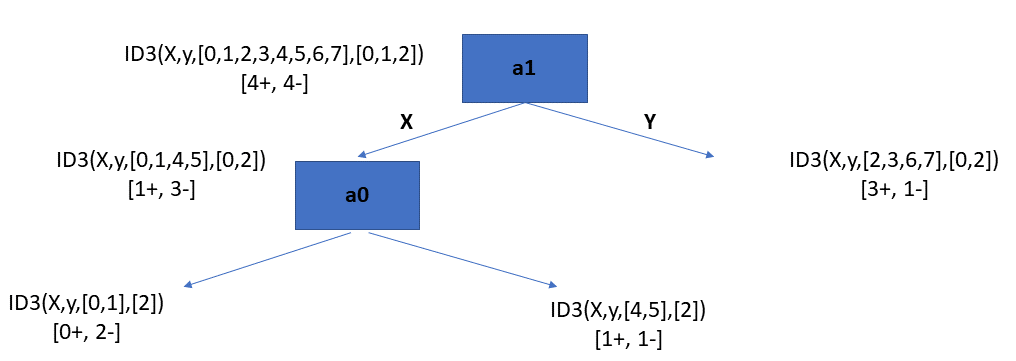

### Table Representation after the Next Split

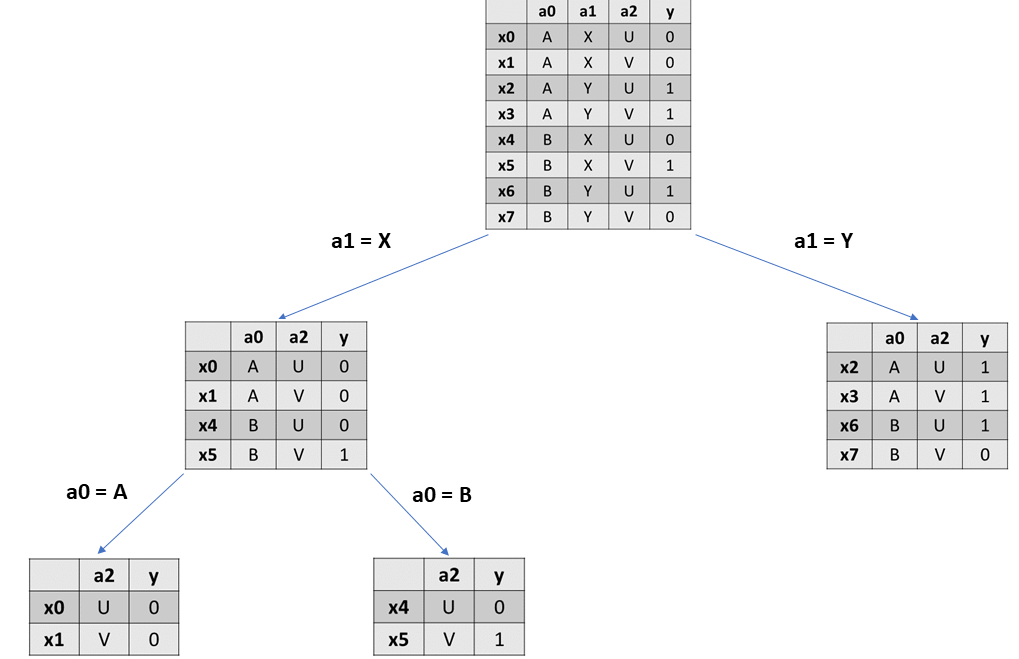

### Pure-Node Stopping Condition

For the recursive call containing examples `[0, 1]`, every target belongs to the same class. ID3 therefore terminates that branch and creates a class-0 leaf.

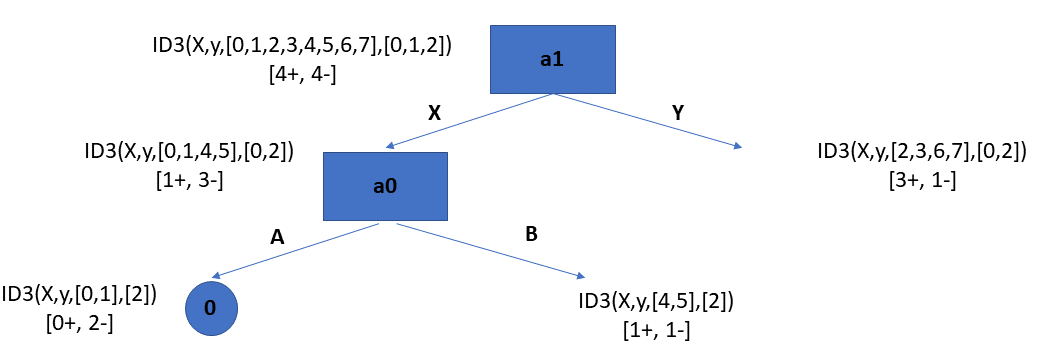

For the branch containing examples `[4, 5]`, only one candidate attribute remains, so the branch is split on that attribute.

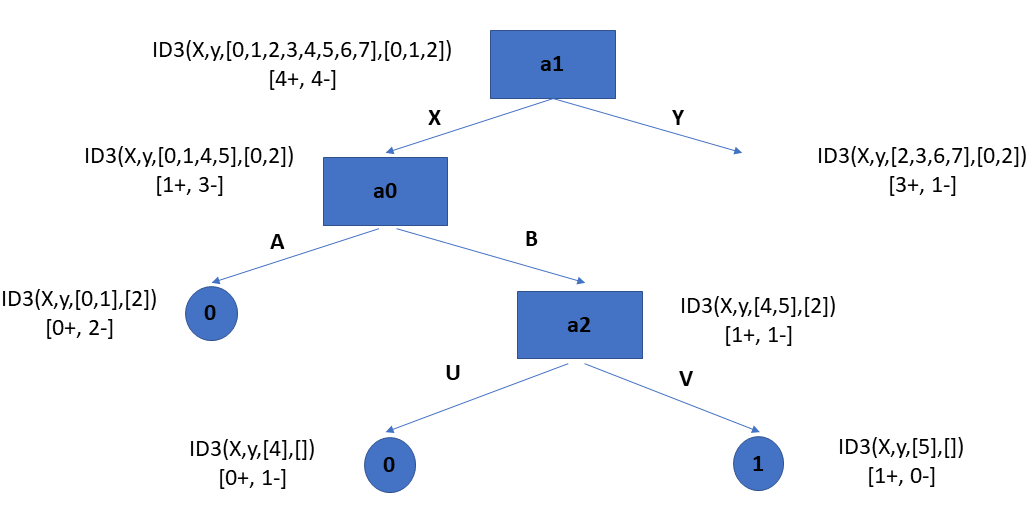

### Completed Tree

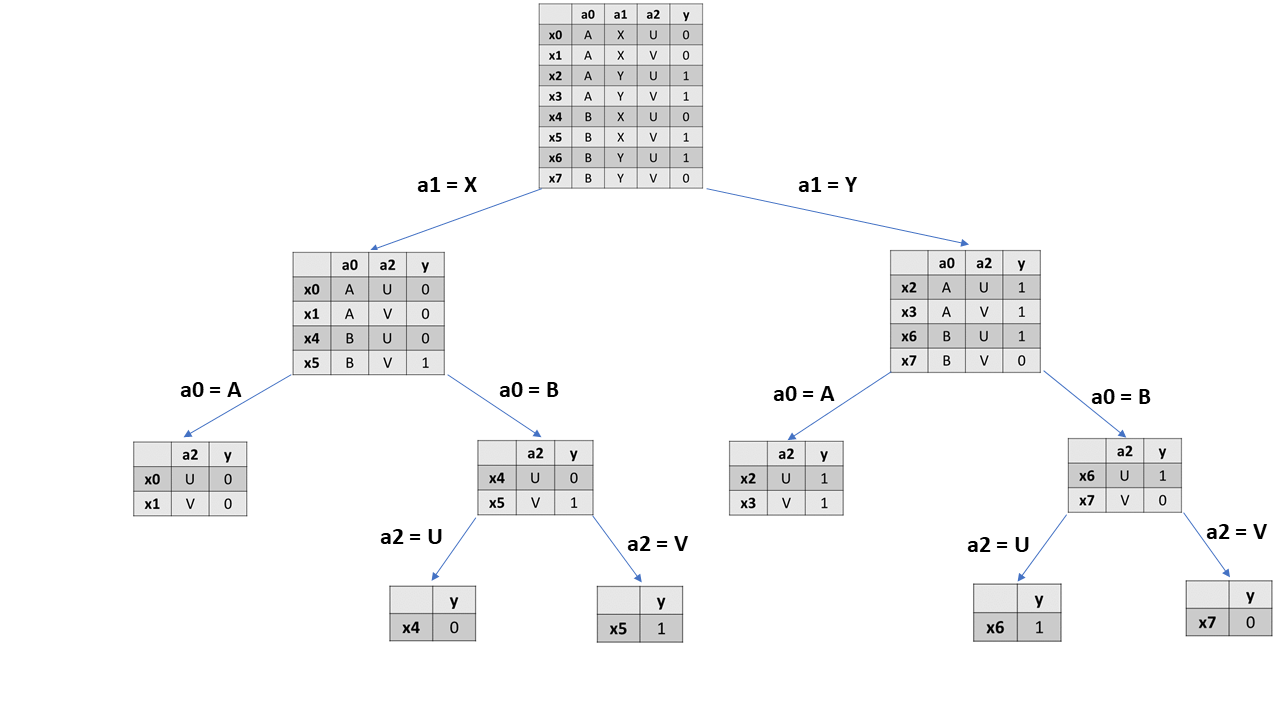

## 7. Reproducing the Tree with scikit-learn

The categorical values are encoded numerically so the same eight-observation problem can be modeled with `DecisionTreeClassifier`.

In [17]:
from sklearn.tree import DecisionTreeClassifier


In [18]:
X= np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]])
y = np.array([0,0,1,1,0,1,1,0])
print(X)
print(y)

[[0 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 1]
 [1 0 0]
 [1 0 1]
 [1 1 0]
 [1 1 1]]
[0 0 1 1 0 1 1 0]


### Depth 1

Entropy is used as the split criterion. With a maximum depth of 1, the learned root split can be compared directly with the manually derived `a1` split.

In [19]:
from sklearn import tree
import matplotlib.pyplot as plt

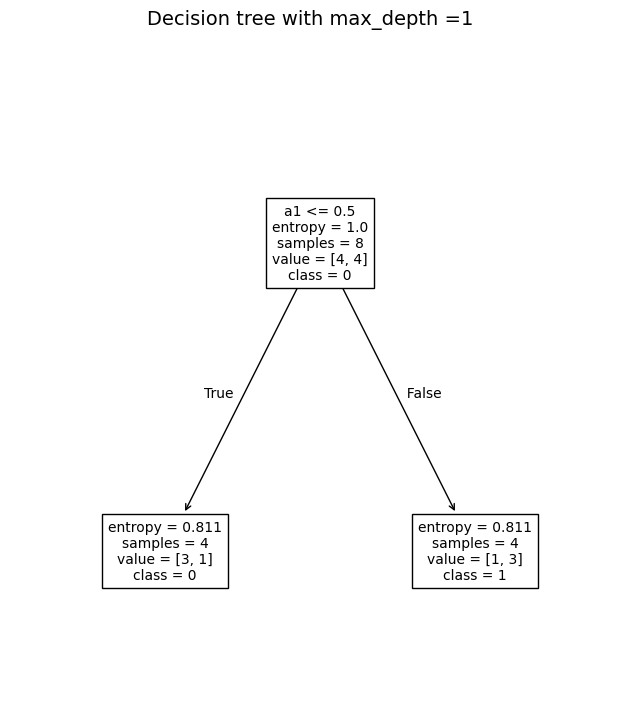

In [20]:
max_depth=1
model = DecisionTreeClassifier(criterion='entropy',max_depth=max_depth)
model = model.fit(X, y)
fig, ax = plt.subplots(figsize=(8,8))
t = tree.plot_tree(model, feature_names=['a0','a1','a2'],fontsize=10, ax=ax,class_names=['0','1'])
s=fig.suptitle('Decision tree with max_depth ={}'.format(max_depth), fontsize=14)

### Entropy Values Reported by the Tree

In [21]:
entropy_from_p1(0.5)

np.float64(1.0)

In [22]:
entropy_from_p1(0.75)

np.float64(0.8112781244591328)

### Depth 2

Increasing the maximum depth allows the next level of splits to be learned.

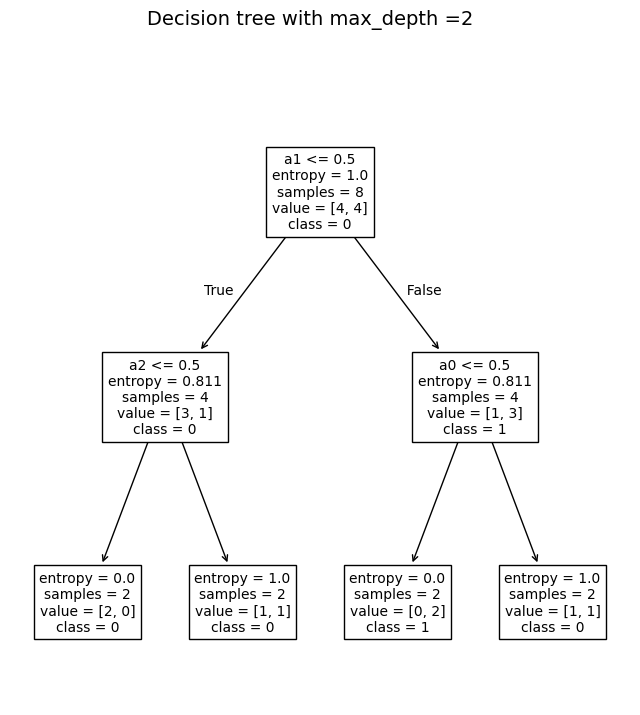

In [23]:
max_depth=2
model = DecisionTreeClassifier(criterion='entropy',max_depth=max_depth)
model = model.fit(X, y)
fig, ax = plt.subplots(figsize=(8,8))
t = tree.plot_tree(model, feature_names=['a0','a1','a2'],fontsize=10, ax=ax,class_names=['0','1'])
s=fig.suptitle('Decision tree with max_depth ={}'.format(max_depth), fontsize=14)

### Depth 3

At depth 3, the learned structure reproduces the complete manually constructed tree.

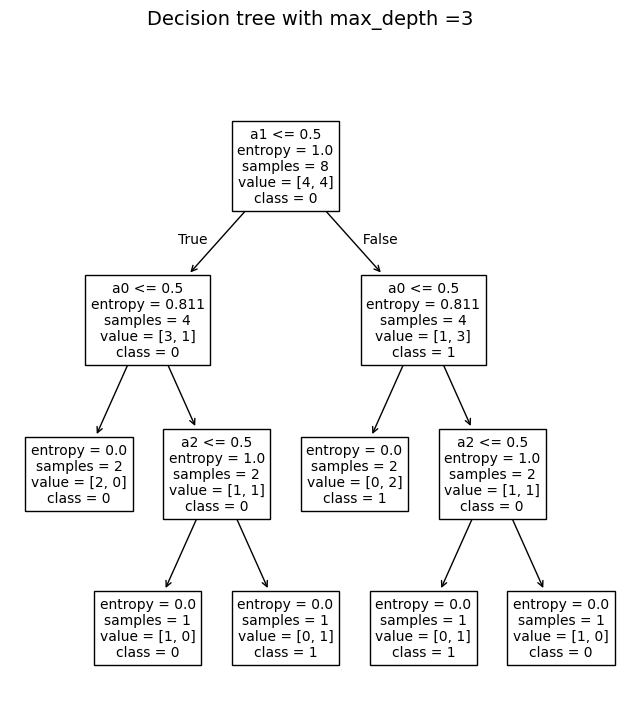

In [24]:
max_depth=3
model = DecisionTreeClassifier(criterion='entropy',max_depth=max_depth)
model = model.fit(X, y)
fig, ax = plt.subplots(figsize=(8,8))
tree.plot_tree(model, feature_names=['a0','a1','a2'],fontsize=10, ax=ax,class_names=['0','1'])
s=fig.suptitle('Decision tree with max_depth ={}'.format(max_depth), fontsize=14)

### Larger Maximum Depth

Increasing the maximum depth further has no effect once all terminal nodes are pure.

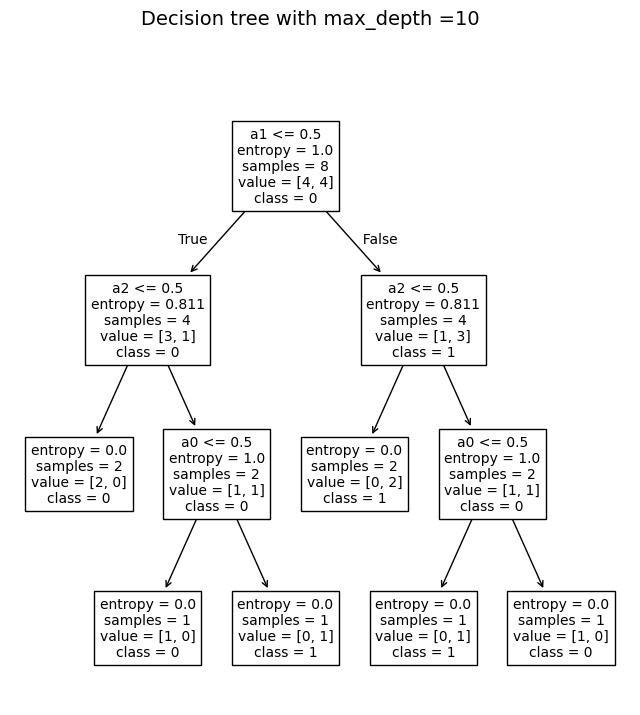

In [25]:
max_depth=10
model = DecisionTreeClassifier(criterion='entropy',max_depth=max_depth)
model = model.fit(X, y)
fig, ax = plt.subplots(figsize=(8,8))
tree.plot_tree(model, feature_names=['a0','a1','a2'],fontsize=10, ax=ax,class_names=['0','1'])
s=fig.suptitle('Decision tree with max_depth ={}'.format(max_depth), fontsize=14)

### Simplified Filled-Tree Visualization

The same fitted tree is displayed without impurity labels to emphasize the final decision structure.

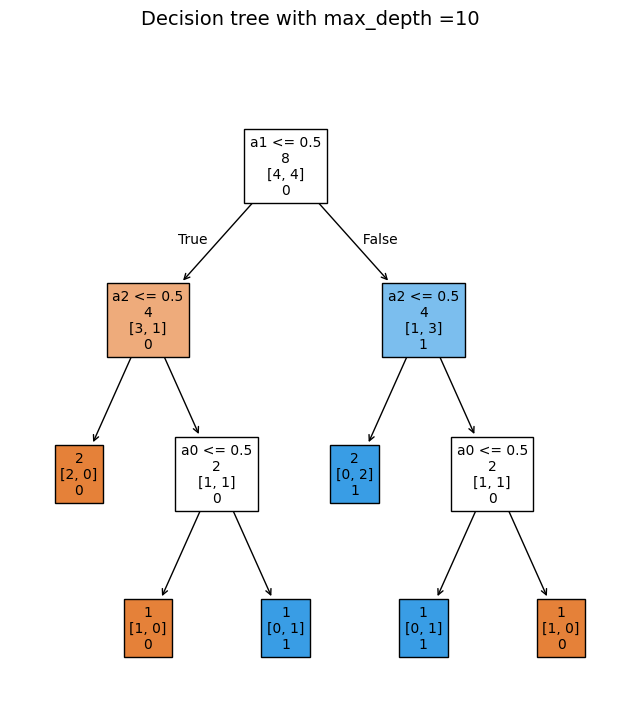

In [26]:
fig, ax = plt.subplots(figsize=(8,8))
tree.plot_tree(model, feature_names=['a0','a1','a2'],fontsize=10, ax=ax,class_names=['0','1'],label='none',impurity=False,filled=True)
s=fig.suptitle('Decision tree with max_depth ={}'.format(max_depth), fontsize=14)

## 8. Key Findings

- Entropy quantifies class impurity at each node.
- Information gain provides a formal criterion for choosing split attributes.
- The manually selected root (`a1`) matches the scikit-learn entropy-based tree.
- Recursive splitting stops naturally when a node becomes pure or no useful attributes remain.
- Maximum depth controls tree growth, but increasing the depth beyond the fully pure structure does not change this small example.
- The two retained entropy implementations produce the same mathematical quantity through different NumPy expressions.